In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import torch
import lightning as L
from pytorch_forecasting import TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer, EncoderNormalizer
from pytorch_forecasting.metrics import MAE, RMSE, SMAPE
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print(f"✅ PyTorch: {torch.__version__}")
print(f"✅ Lightning: {L.__version__}")
print(f"✅ GPU: {torch.cuda.is_available()}")

# Carregar dataset
df = pd.read_parquet('../data/processed/dataset_features_v2.parquet')
df['data'] = pd.to_datetime(df['data'])
df = df.sort_values('data').reset_index(drop=True)

print(f"\n✅ Dataset: {df.shape}")
print(f"Período: {df['data'].min().date()} → {df['data'].max().date()}")

✅ PyTorch: 2.10.0+cpu
✅ Lightning: 2.6.1
✅ GPU: False

✅ Dataset: (2242, 55)
Período: 2018-02-12 → 2024-12-28


In [4]:
# ============================================================
# PREPARAÇÃO DOS DADOS PARA O TFT
# ============================================================

# O TFT requer:
# 1. Coluna de grupo (série temporal identificada)
# 2. Índice temporal inteiro
# 3. Separação explícita de features estáticas vs variantes no tempo

df_tft = df.copy()

# Adicionar grupo (só temos uma série — MT)
df_tft['grupo'] = 'MT'

# Índice temporal inteiro (obrigatório para o TFT)
df_tft['time_idx'] = range(len(df_tft))

# Features variantes no tempo — climáticas e epidemiológicas
TIME_VARYING_KNOWN = [
    # Climáticas com lag (conhecidas no momento da previsão)
    'precipitacao_total', 'temp_media', 'temp_max', 'temp_min',
    'umidade_media', 'radiacao_mj', 'ndvi', 'ndwi', 'oni_index',
    # Sazonalidade
    'mes_seno', 'mes_cosseno', 'semana_seno', 'semana_cosseno',
    'dia_ano', 'mes', 'semana_ano',
    # Ciclo epidêmico
    'ciclo_epidemico', 'anos_desde_pico',
]

TIME_VARYING_UNKNOWN = [
    # Lags de casos (desconhecidos no futuro)
    'casos_lag_7d', 'casos_lag_14d', 'casos_lag_21d', 'casos_lag_28d',
    'casos_mm_7d', 'casos_mm_14d', 'casos_mm_28d',
    # Lags climáticos
    'umidade_lag_28d', 'umidade_lag_35d', 'umidade_lag_42d',
    'precip_lag_28d', 'precip_lag_35d', 'precip_lag_42d',
    'precip_acum_7d', 'precip_acum_14d', 'precip_acum_28d',
    'radiacao_lag_28d', 'radiacao_mm_14d',
]

# Target
TARGET = 'casos'

# Horizonte de previsão — 28 dias (4 semanas)
MAX_PREDICTION_LENGTH = 28
MAX_ENCODER_LENGTH = 90  # 3 meses de histórico

# Divisão temporal — últimos 20% para teste
total = len(df_tft)
corte_treino = int(total * 0.80)

print(f"✅ Preparação concluída:")
print(f"   Total: {total} registros")
print(f"   Treino: {corte_treino} registros")
print(f"   Teste: {total - corte_treino} registros")
print(f"   Encoder length: {MAX_ENCODER_LENGTH} dias")
print(f"   Prediction length: {MAX_PREDICTION_LENGTH} dias")
print(f"   Features conhecidas no futuro: {len(TIME_VARYING_KNOWN)}")
print(f"   Features desconhecidas no futuro: {len(TIME_VARYING_UNKNOWN)}")

✅ Preparação concluída:
   Total: 2242 registros
   Treino: 1793 registros
   Teste: 449 registros
   Encoder length: 90 dias
   Prediction length: 28 dias
   Features conhecidas no futuro: 18
   Features desconhecidas no futuro: 18


In [7]:
# ============================================================
# CRIAR DATASETS TFT
# ============================================================

# Garantir que não há NaNs
df_tft = df_tft.ffill().bfill()

# Dataset de treino
training = TimeSeriesDataSet(
    df_tft[df_tft.time_idx <= corte_treino],
    time_idx='time_idx',
    target=TARGET,
    group_ids=['grupo'],
    max_encoder_length=MAX_ENCODER_LENGTH,
    max_prediction_length=MAX_PREDICTION_LENGTH,
    time_varying_known_reals=TIME_VARYING_KNOWN,
    time_varying_unknown_reals=TIME_VARYING_UNKNOWN,
    target_normalizer=EncoderNormalizer(),
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
)

# Dataset de validação
validation = TimeSeriesDataSet.from_dataset(
    training,
    df_tft,
    predict=True,
    stop_randomization=True
)

# DataLoaders
train_loader = training.to_dataloader(train=True, batch_size=32, num_workers=0)
val_loader = validation.to_dataloader(train=False, batch_size=32, num_workers=0)

print(f"✅ Datasets criados!")
print(f"   Treino: {len(training)} sequências")
print(f"   Validação: {len(validation)} sequências")

✅ Datasets criados!
   Treino: 1677 sequências
   Validação: 1 sequências


In [8]:
# Ajustar divisão — usar últimos 30% para validação
corte_treino_v2 = int(total * 0.70)

training_v2 = TimeSeriesDataSet(
    df_tft[df_tft.time_idx <= corte_treino_v2],
    time_idx='time_idx',
    target=TARGET,
    group_ids=['grupo'],
    max_encoder_length=MAX_ENCODER_LENGTH,
    max_prediction_length=MAX_PREDICTION_LENGTH,
    time_varying_known_reals=TIME_VARYING_KNOWN,
    time_varying_unknown_reals=TIME_VARYING_UNKNOWN,
    target_normalizer=EncoderNormalizer(),
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
)

# Validação — próximos 28 dias após o corte
validation_v2 = TimeSeriesDataSet.from_dataset(
    training_v2,
    df_tft[df_tft.time_idx <= corte_treino_v2 + MAX_PREDICTION_LENGTH],
    min_prediction_idx=corte_treino_v2 + 1,
    stop_randomization=True
)

train_loader = training_v2.to_dataloader(train=True, batch_size=32, num_workers=0)
val_loader = validation_v2.to_dataloader(train=False, batch_size=32, num_workers=0)

print(f"✅ Datasets v2 criados!")
print(f"   Corte treino: {corte_treino_v2} (70%)")
print(f"   Treino: {len(training_v2)} sequências")
print(f"   Validação: {len(validation_v2)} sequências")

✅ Datasets v2 criados!
   Corte treino: 1569 (70%)
   Treino: 1453 sequências
   Validação: 1 sequências


In [9]:
# Abordagem manual — dividir por time_idx
corte_val = corte_treino_v2 + MAX_PREDICTION_LENGTH

validation_v3 = TimeSeriesDataSet.from_dataset(
    training_v2,
    df_tft,
    min_prediction_idx=corte_treino_v2 - MAX_ENCODER_LENGTH + 1,
    stop_randomization=True
)

val_loader = validation_v3.to_dataloader(train=False, batch_size=32, num_workers=0)

print(f"✅ Validação v3: {len(validation_v3)} sequências")
print(f"   Período validação: {df_tft['data'].iloc[corte_treino_v2].date()} → {df_tft['data'].iloc[-1].date()}")

✅ Validação v3: 735 sequências
   Período validação: 2023-02-25 → 2024-12-28


In [15]:
# Converter target para float
df_tft['casos'] = df_tft['casos'].astype(float)

# Recriar datasets com tipo correto
training_v2 = TimeSeriesDataSet(
    df_tft[df_tft.time_idx <= corte_treino_v2],
    time_idx='time_idx',
    target=TARGET,
    group_ids=['grupo'],
    max_encoder_length=MAX_ENCODER_LENGTH,
    max_prediction_length=MAX_PREDICTION_LENGTH,
    time_varying_known_reals=TIME_VARYING_KNOWN,
    time_varying_unknown_reals=TIME_VARYING_UNKNOWN,
    target_normalizer=EncoderNormalizer(),
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
)

validation_v3 = TimeSeriesDataSet.from_dataset(
    training_v2,
    df_tft,
    min_prediction_idx=corte_treino_v2 - MAX_ENCODER_LENGTH + 1,
    stop_randomization=True
)

train_loader = training_v2.to_dataloader(train=True, batch_size=32, num_workers=0)
val_loader = validation_v3.to_dataloader(train=False, batch_size=32, num_workers=0)

print(f"✅ Datasets recriados com target float!")
print(f"   Treino: {len(training_v2)} | Validação: {len(validation_v3)}")

✅ Datasets recriados com target float!
   Treino: 1453 | Validação: 735


In [17]:
# ============================================================
# CONSTRUIR O MODELO TFT
# ============================================================

from lightning.pytorch.callbacks import EarlyStopping
from lightning.pytorch import Trainer, seed_everything

seed_everything(42)

tft = TemporalFusionTransformer.from_dataset(
    training_v2,
    learning_rate=0.03,
    hidden_size=32,
    attention_head_size=2,
    dropout=0.1,
    hidden_continuous_size=16,
    loss=MAE(),
    optimizer='adam',
    log_interval=10,
    reduce_on_plateau_patience=4,
)

print(f"✅ TFT criado! Parâmetros: {tft.size()/1e3:.1f}K")

trainer = Trainer(
    max_epochs=50,
    accelerator='cpu',
    gradient_clip_val=0.1,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=10, mode='min')
    ],
    enable_progress_bar=True,
    logger=False,
    enable_model_summary=False,
)

print("\n🔄 Treinando TFT...")
trainer.fit(
    tft,
    train_dataloaders=train_loader,
    val_dataloaders=val_loader
)
print("✅ Treinamento concluído!")

Seed set to 42
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


Output()

✅ TFT criado! Parâmetros: 191.9K

🔄 Treinando TFT...


✅ Treinamento concluído!


In [18]:
# ============================================================
# AVALIAÇÃO DO TFT
# ============================================================

# Fazer predições no conjunto de teste
predictions = tft.predict(val_loader, return_y=True, trainer_kwargs=dict(accelerator='cpu'))

y_pred = predictions.output.numpy().flatten()
y_real = predictions.y[0].numpy().flatten()

# Clipar negativos
y_pred = np.clip(y_pred, 0, None)

# Métricas
mae_tft = mean_absolute_error(y_real, y_pred)
rmse_tft = np.sqrt(mean_squared_error(y_real, y_pred))
r2_tft = r2_score(y_real, y_pred)

print(f"📊 TFT — Resultados:")
print(f"  MAE:  {mae_tft:.2f} casos/dia")
print(f"  RMSE: {rmse_tft:.2f} casos/dia")
print(f"  R²:   {r2_tft:.3f}")

print(f"\n🏆 COMPARAÇÃO COM MODELOS ANTERIORES:")
print(f"{'Modelo':<30} {'R²':>8} {'MAE':>8}")
print(f"{'-'*48}")
print(f"{'Rolling Window LightGBM':<30} {'0.892':>8} {'17.69':>8}")
print(f"{'LightGBM otimizado':<30} {'0.871':>8} {'21.83':>8}")
print(f"{'CNN + BiLSTM':<30} {'0.756':>8} {'33.34':>8}")
print(f"{'LSTM v2':<30} {'0.664':>8} {'38.75':>8}")
print(f"{'TFT':<30} {r2_tft:>8.3f} {mae_tft:>8.2f}")

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


📊 TFT — Resultados:
  MAE:  43.97 casos/dia
  RMSE: 68.94 casos/dia
  R²:   0.459

🏆 COMPARAÇÃO COM MODELOS ANTERIORES:
Modelo                               R²      MAE
------------------------------------------------
Rolling Window LightGBM           0.892    17.69
LightGBM otimizado                0.871    21.83
CNN + BiLSTM                      0.756    33.34
LSTM v2                           0.664    38.75
TFT                               0.459    43.97


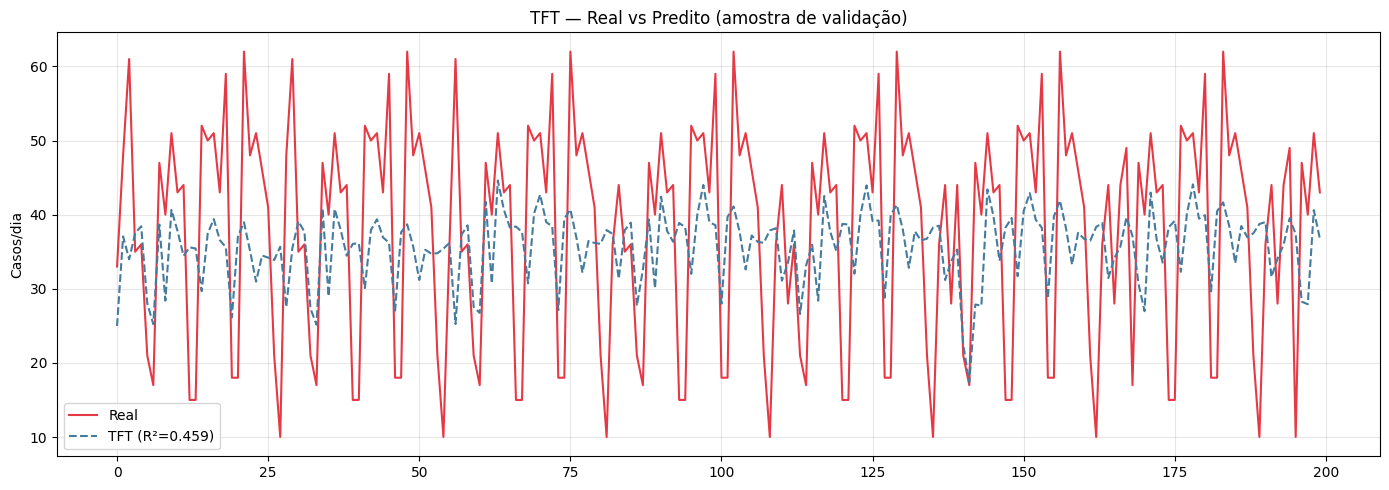


Análise dos erros:
  Média: -12.1 (bias)
  Std:   67.9
  Min:   -313.2
  Max:   269.2

  Subestima (pred < real): 11448 vezes (55.6%)
  Superestima (pred > real): 9132 vezes (44.4%)


In [19]:
# Visualizar predições
fig, ax = plt.subplots(figsize=(14, 5))

# Pegar amostra das predições
n = min(200, len(y_real))
ax.plot(range(n), y_real[:n], color='#e63946', linewidth=1.5, label='Real')
ax.plot(range(n), y_pred[:n], color='#457b9d', linewidth=1.5, 
        label=f'TFT (R²={r2_tft:.3f})', linestyle='--')
ax.set_title('TFT — Real vs Predito (amostra de validação)')
ax.set_ylabel('Casos/dia')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Distribuição dos erros
erros = y_pred - y_real
print(f"\nAnálise dos erros:")
print(f"  Média: {erros.mean():.1f} (bias)")
print(f"  Std:   {erros.std():.1f}")
print(f"  Min:   {erros.min():.1f}")
print(f"  Max:   {erros.max():.1f}")
print(f"\n  Subestima (pred < real): {(erros < 0).sum()} vezes ({(erros<0).mean()*100:.1f}%)")
print(f"  Superestima (pred > real): {(erros > 0).sum()} vezes ({(erros>0).mean()*100:.1f}%)")

In [20]:
# Agregar para dados semanais — como Pillay et al. (2026)
df_semanal = df.copy()
df_semanal['data'] = pd.to_datetime(df_semanal['data'])
df_semanal['semana_data'] = df_semanal['data'].dt.to_period('W').dt.start_time

# Agregar por semana
agg_dict = {
    'casos': 'sum',
    'precipitacao_total': 'sum',
    'temp_media': 'mean',
    'temp_max': 'max',
    'temp_min': 'min',
    'umidade_media': 'mean',
    'radiacao_mj': 'sum',
    'ndvi': 'mean',
    'ndwi': 'mean',
    'oni_index': 'mean',
    'mes_seno': 'mean',
    'mes_cosseno': 'mean',
    'semana_seno': 'mean',
    'semana_cosseno': 'mean',
    'ciclo_epidemico': 'first',
    'anos_desde_pico': 'first',
    'dia_ano': 'mean',
    'mes': 'first',
    'semana_ano': 'first',
}

df_week = df_semanal.groupby('semana_data').agg(agg_dict).reset_index()
df_week = df_week.rename(columns={'semana_data': 'data'})
df_week['grupo'] = 'MT'
df_week['time_idx'] = range(len(df_week))
df_week['casos'] = df_week['casos'].astype(float)

# Recalcular lags semanais
for lag in [1, 2, 3, 4]:
    df_week[f'casos_lag_{lag}w'] = df_week['casos'].shift(lag)
for janela in [4, 8]:
    df_week[f'casos_mm_{janela}w'] = df_week['casos'].shift(1).rolling(janela).mean()

df_week = df_week.dropna().reset_index(drop=True)
df_week['time_idx'] = range(len(df_week))

print(f"✅ Dataset semanal: {df_week.shape}")
print(f"   Semanas: {len(df_week)}")
print(f"   Período: {df_week['data'].min().date()} → {df_week['data'].max().date()}")
print(f"\nTarget semanal (casos/semana):")
print(df_week['casos'].describe().round(1))

✅ Dataset semanal: (319, 28)
   Semanas: 319
   Período: 2018-04-09 → 2024-12-23

Target semanal (casos/semana):
count     319.0
mean      461.0
std       471.0
min         5.0
25%       114.5
50%       255.0
75%       654.5
max      2166.0
Name: casos, dtype: float64


In [21]:
from pathlib import Path
import pandas as pd
import numpy as np

# Carregar todos os anos do SINAN
SINAN_DIR = Path('../data/processed/sinan')

dfs = []
for arq in sorted(SINAN_DIR.glob('*.parquet')):
    df_raw = pd.read_parquet(arq)
    df_raw['ano'] = int(arq.stem.split('_')[-1])
    dfs.append(df_raw)

dengue_raw = pd.concat(dfs, ignore_index=True)

# Filtrar apenas confirmados
confirmados = dengue_raw[dengue_raw['CLASSI_FIN'].isin(['10','11','12'])].copy()

# Converter data
confirmados['DT_NOTIFIC'] = pd.to_datetime(confirmados['DT_NOTIFIC'])
confirmados['semana'] = confirmados['DT_NOTIFIC'].dt.to_period('W').dt.start_time

# Agregar por município e semana
casos_municipio = confirmados.groupby(
    ['semana', 'ID_MUNICIP']
).size().reset_index(name='casos')

# Verificar top municípios
top_mun = casos_municipio.groupby('ID_MUNICIP')['casos'].sum().sort_values(ascending=False)
print(f"✅ Total municípios: {casos_municipio['ID_MUNICIP'].nunique()}")
print(f"Total semanas: {casos_municipio['semana'].nunique()}")
print(f"\nTop 15 municípios por casos:")
print(top_mun.head(15))

✅ Total municípios: 140
Total semanas: 366

Top 15 municípios por casos:
ID_MUNICIP
510704    13220
510790    13096
510340     8958
510795     8389
510792     7868
510622     5635
510525     5598
510760     5009
510250     4897
510025     4365
510840     4024
510267     3759
510675     3453
510335     3010
510263     2821
Name: casos, dtype: int64


In [24]:
# Filtrar municípios com pelo menos 100 semanas de dados
semanas_por_mun = casos_municipio.groupby('ID_MUNICIP')['semana'].count()
mun_validos = semanas_por_mun[semanas_por_mun >= 100].index.tolist()
print(f"Municípios com ≥100 semanas: {len(mun_validos)}")

# Filtrar casos
casos_filt = casos_municipio[casos_municipio['ID_MUNICIP'].isin(mun_validos)].copy()

# Carregar dados climáticos semanais (Cuiabá como proxy para todo MT)
# Agregação semanal do INMET
inmet = pd.read_parquet('../data/processed/inmet/inmet_cuiaba_2018_2024.parquet')
inmet['data'] = pd.to_datetime(inmet['data'])
inmet['semana'] = inmet['data'].dt.to_period('W').dt.start_time

inmet_semanal = inmet.groupby('semana').agg(
    precipitacao_total=('precipitacao_total', 'sum'),
    temp_media=('temp_media', 'mean'),
    temp_max=('temp_max', 'max'),
    temp_min=('temp_min', 'min'),
    umidade_media=('umidade_media', 'mean'),
).reset_index()

# Carregar ONI
import requests
from io import StringIO

resp = requests.get("https://www.cpc.ncep.noaa.gov/data/indices/oni.ascii.txt", timeout=30)
oni_raw = pd.read_csv(StringIO(resp.text), sep=r'\s+')
seas_map = {'DJF':1,'JFM':2,'FMA':3,'MAM':4,'AMJ':5,'MJJ':6,
            'JJA':7,'JAS':8,'ASO':9,'SON':10,'OND':11,'NDJ':12}
oni_raw['mes'] = oni_raw['SEAS'].map(seas_map)
oni_raw['data'] = pd.to_datetime(dict(year=oni_raw['YR'], month=oni_raw['mes'], day=1))
oni_raw = oni_raw[oni_raw['YR'].between(2018, 2024)][['data','ANOM']].rename(columns={'ANOM':'oni_index'})

# Merge clima + ONI
casos_filt = casos_filt.merge(inmet_semanal, on='semana', how='left')
casos_filt['mes'] = pd.to_datetime(casos_filt['semana']).dt.month
casos_filt['mes_periodo'] = pd.to_datetime(casos_filt['semana']).dt.to_period('M').dt.to_timestamp()
casos_filt = casos_filt.merge(oni_raw.rename(columns={'data':'mes_periodo'}), 
                               on='mes_periodo', how='left')

# Features sazonais
casos_filt['mes_seno'] = np.sin(2 * np.pi * casos_filt['mes'] / 12)
casos_filt['mes_cosseno'] = np.cos(2 * np.pi * casos_filt['mes'] / 12)
casos_filt['semana_ano'] = pd.to_datetime(casos_filt['semana']).dt.isocalendar().week.astype(int)
casos_filt['semana_seno'] = np.sin(2 * np.pi * casos_filt['semana_ano'] / 52)
casos_filt['semana_cosseno'] = np.cos(2 * np.pi * casos_filt['semana_ano'] / 52)

# Lags de casos por município
casos_filt = casos_filt.sort_values(['ID_MUNICIP', 'semana']).reset_index(drop=True)
for lag in [1, 2, 3, 4]:
    casos_filt[f'casos_lag_{lag}w'] = casos_filt.groupby('ID_MUNICIP')['casos'].shift(lag)
for janela in [4, 8]:
    casos_filt[f'casos_mm_{janela}w'] = casos_filt.groupby('ID_MUNICIP')['casos'].shift(1).rolling(janela).mean()

# Limpeza final
casos_filt['casos'] = casos_filt['casos'].astype(float)
casos_filt = casos_filt.dropna().reset_index(drop=True)

# Índice temporal por município
casos_filt['time_idx'] = casos_filt.groupby('ID_MUNICIP').cumcount()

print(f"✅ Dataset multi-município criado:")
print(f"   Shape: {casos_filt.shape}")
print(f"   Municípios: {casos_filt['ID_MUNICIP'].nunique()}")
print(f"   Semanas por município (média): {casos_filt.groupby('ID_MUNICIP')['time_idx'].max().mean():.0f}")
print(f"   Total sequências disponíveis: {len(casos_filt):,}")
print(f"\nAmostra:")
print(casos_filt.head(3))

Municípios com ≥100 semanas: 79
✅ Dataset multi-município criado:
   Shape: (13937, 23)
   Municípios: 79
   Semanas por município (média): 175
   Total sequências disponíveis: 13,937

Amostra:
      semana ID_MUNICIP  casos  precipitacao_total  temp_media  temp_max  \
0 2018-08-13     510020    2.0                 0.0   27.007676      38.6   
1 2018-08-20     510020    2.0                 5.0   22.143452      38.2   
2 2018-08-27     510020    1.0                 0.4   27.739458      38.0   

   temp_min  umidade_media  mes mes_periodo  ...  semana_ano  semana_seno  \
0      18.9      46.490373    8  2018-08-01  ...          33    -0.748511   
1      11.9      59.059524    8  2018-08-01  ...          34    -0.822984   
2      15.0      42.225259    8  2018-08-01  ...          35    -0.885456   

   semana_cosseno  casos_lag_1w  casos_lag_2w  casos_lag_3w  casos_lag_4w  \
0       -0.663123           1.0           2.0           1.0           1.0   
1       -0.568065           2.0       

In [23]:
import os

# Verificar estrutura da pasta processed
for item in sorted(Path('../data/processed').rglob('*.parquet')):
    print(item)

..\data\processed\dataset_features.parquet
..\data\processed\dataset_features_v2.parquet
..\data\processed\gee_ndvi_ndwi_2018_2024.parquet
..\data\processed\gee_ndvi_ndwi_blend_2018_2024.parquet
..\data\processed\inmet\inmet_cuiaba_2018_2024.parquet
..\data\processed\sinan\dengue_mt_2018.parquet
..\data\processed\sinan\dengue_mt_2019.parquet
..\data\processed\sinan\dengue_mt_2020.parquet
..\data\processed\sinan\dengue_mt_2021.parquet
..\data\processed\sinan\dengue_mt_2022.parquet
..\data\processed\sinan\dengue_mt_2023.parquet
..\data\processed\sinan\dengue_mt_2024.parquet


In [25]:
# ============================================================
# DATASET TFT MULTI-MUNICÍPIO
# ============================================================

TIME_VARYING_KNOWN_MM = [
    'precipitacao_total', 'temp_media', 'temp_max', 'temp_min',
    'umidade_media', 'oni_index',
    'mes_seno', 'mes_cosseno', 'semana_seno', 'semana_cosseno',
]

TIME_VARYING_UNKNOWN_MM = [
    'casos_lag_1w', 'casos_lag_2w', 'casos_lag_3w', 'casos_lag_4w',
    'casos_mm_4w', 'casos_mm_8w',
]

MAX_ENCODER_LENGTH_MM = 52   # 1 ano de histórico — como Pillay et al.
MAX_PREDICTION_LENGTH_MM = 4  # 4 semanas à frente

# Divisão temporal — últimos 20% para teste
max_time_idx = casos_filt.groupby('ID_MUNICIP')['time_idx'].max().min()
corte_mm = int(max_time_idx * 0.80)

print(f"Max time_idx (menor série): {max_time_idx}")
print(f"Corte treino: {corte_mm}")

training_mm = TimeSeriesDataSet(
    casos_filt[casos_filt.time_idx <= corte_mm],
    time_idx='time_idx',
    target='casos',
    group_ids=['ID_MUNICIP'],
    max_encoder_length=MAX_ENCODER_LENGTH_MM,
    max_prediction_length=MAX_PREDICTION_LENGTH_MM,
    time_varying_known_reals=TIME_VARYING_KNOWN_MM,
    time_varying_unknown_reals=TIME_VARYING_UNKNOWN_MM,
    target_normalizer=GroupNormalizer(groups=['ID_MUNICIP'], transformation='softplus'),
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
)

validation_mm = TimeSeriesDataSet.from_dataset(
    training_mm,
    casos_filt,
    min_prediction_idx=corte_mm - MAX_ENCODER_LENGTH_MM + 1,
    stop_randomization=True
)

train_loader_mm = training_mm.to_dataloader(train=True, batch_size=64, num_workers=0)
val_loader_mm = validation_mm.to_dataloader(train=False, batch_size=64, num_workers=0)

print(f"\n✅ Datasets multi-município criados!")
print(f"   Treino: {len(training_mm):,} sequências")
print(f"   Validação: {len(validation_mm):,} sequências")

Max time_idx (menor série): 91
Corte treino: 72

✅ Datasets multi-município criados!
   Treino: 1,422 sequências
   Validação: 9,592 sequências


In [26]:
# ============================================================
# TFT MULTI-MUNICÍPIO
# ============================================================

seed_everything(42)

tft_mm = TemporalFusionTransformer.from_dataset(
    training_mm,
    learning_rate=0.03,
    hidden_size=64,           # maior que antes — mais dados
    attention_head_size=4,
    dropout=0.1,
    hidden_continuous_size=32,
    loss=MAE(),
    optimizer='adam',
    log_interval=10,
    reduce_on_plateau_patience=4,
)

print(f"✅ TFT multi-município criado!")
print(f"   Parâmetros: {tft_mm.size()/1e3:.1f}K")

trainer_mm = Trainer(
    max_epochs=50,
    accelerator='cpu',
    gradient_clip_val=0.1,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=10, mode='min')
    ],
    enable_progress_bar=True,
    logger=False,
    enable_model_summary=False,
)

print("\n🔄 Treinando TFT multi-município...")
trainer_mm.fit(
    tft_mm,
    train_dataloaders=train_loader_mm,
    val_dataloaders=val_loader_mm
)
print("✅ Treinamento concluído!")

Seed set to 42
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


Output()

✅ TFT multi-município criado!
   Parâmetros: 431.4K

🔄 Treinando TFT multi-município...


✅ Treinamento concluído!


In [27]:
# ============================================================
# AVALIAÇÃO TFT MULTI-MUNICÍPIO
# ============================================================

predictions_mm = tft_mm.predict(
    val_loader_mm, 
    return_y=True, 
    trainer_kwargs=dict(accelerator='cpu')
)

y_pred_mm = predictions_mm.output.numpy()
y_real_mm = predictions_mm.y[0].numpy()

# Métricas globais (todos os municípios)
y_pred_flat = np.clip(y_pred_mm.flatten(), 0, None)
y_real_flat = y_real_mm.flatten()

mae_mm = mean_absolute_error(y_real_flat, y_pred_flat)
r2_mm = r2_score(y_real_flat, y_pred_flat)

print(f"📊 TFT Multi-Município — Resultado Global:")
print(f"  MAE: {mae_mm:.2f} | R²: {r2_mm:.3f}")

# Avaliar especificamente Cuiabá e Várzea Grande
# Identificar índices de cada município na validação
indices_mm = predictions_mm.index

# Criar DataFrame com resultados
resultados_pred = []
for i, idx in enumerate(indices_mm):
    municipio = idx[0] if isinstance(idx, tuple) else idx
    resultados_pred.append({
        'municipio': municipio,
        'y_real': y_real_mm[i].mean(),
        'y_pred': np.clip(y_pred_mm[i], 0, None).mean()
    })

df_pred = pd.DataFrame(resultados_pred)

# Filtrar Cuiabá e Várzea Grande
cuiaba = df_pred[df_pred['municipio'] == '510340']
vg = df_pred[df_pred['municipio'] == '510790']

print(f"\n🏙️ Cuiabá (510340):")
if len(cuiaba) > 0:
    r2_cba = r2_score(cuiaba['y_real'], cuiaba['y_pred'])
    mae_cba = mean_absolute_error(cuiaba['y_real'], cuiaba['y_pred'])
    print(f"  MAE={mae_cba:.2f} | R²={r2_cba:.3f} | Sequências: {len(cuiaba)}")

print(f"\n🏙️ Várzea Grande (510790):")
if len(vg) > 0:
    r2_vg = r2_score(vg['y_real'], vg['y_pred'])
    mae_vg = mean_absolute_error(vg['y_real'], vg['y_pred'])
    print(f"  MAE={mae_vg:.2f} | R²={r2_vg:.3f} | Sequências: {len(vg)}")

print(f"\n🏆 COMPARAÇÃO FINAL:")
print(f"{'Modelo':<35} {'R²':>8} {'MAE':>8}")
print(f"{'-'*53}")
print(f"{'Rolling Window LightGBM':<35} {'0.892':>8} {'17.69':>8}")
print(f"{'LightGBM otimizado':<35} {'0.871':>8} {'21.83':>8}")
print(f"{'CNN + BiLSTM':<35} {'0.756':>8} {'33.34':>8}")
print(f"{'LSTM v2':<35} {'0.664':>8} {'38.75':>8}")
print(f"{'TFT série única (diário)':<35} {'0.459':>8} {'43.97':>8}")
print(f"{'TFT multi-município (semanal)':<35} {r2_mm:>8.3f} {mae_mm:>8.2f}")

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


📊 TFT Multi-Município — Resultado Global:
  MAE: 9.27 | R²: 0.230


TypeError: 'NoneType' object is not iterable

📊 TFT Multi-Município — Resultado Global:
  MAE: 9.27 casos/semana
  R²:  0.230


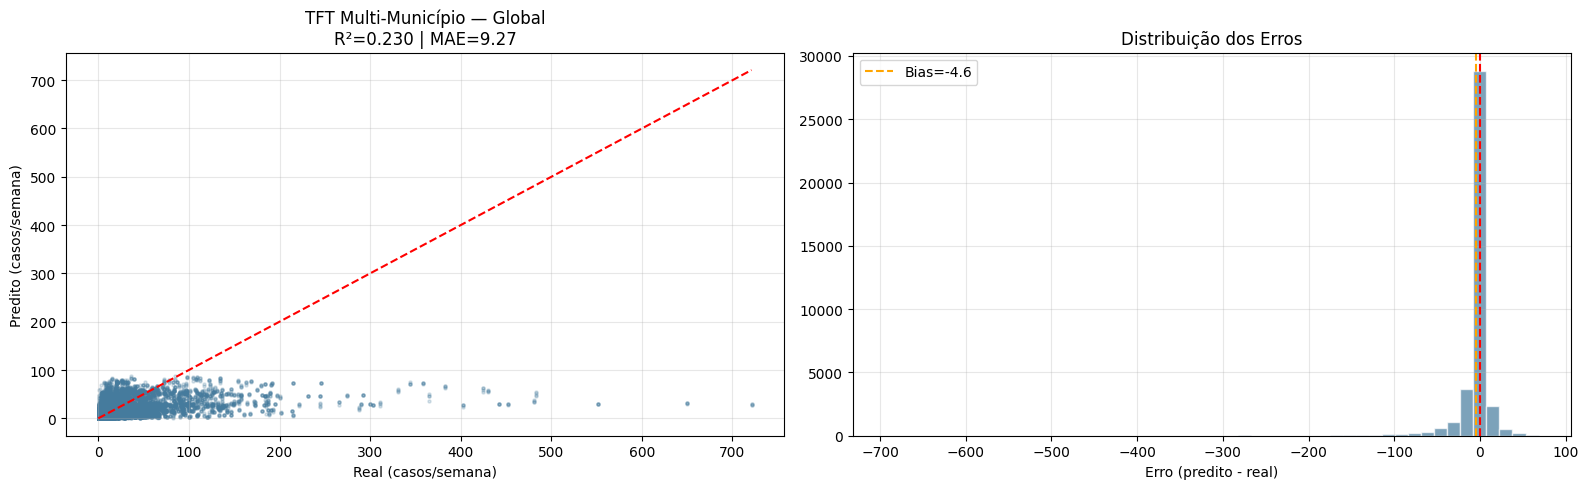


🏆 COMPARAÇÃO FINAL:
Modelo                                    R²      MAE   Granularidade
-----------------------------------------------------------------
Rolling Window LightGBM                0.892    17.69          diário
LightGBM otimizado                     0.871    21.83          diário
CNN + BiLSTM                           0.756    33.34          diário
LSTM v2                                0.664    38.75          diário
TFT série única (diário)               0.459    43.97          diário
TFT multi-município (semanal)          0.230     9.27         semanal

⚠️  Nota: MAE não comparável diretamente — unidades diferentes (dia vs semana)


In [28]:
# Avaliar por município diretamente no dataset de validação
casos_val = casos_filt[casos_filt.time_idx > corte_mm].copy()

# Métricas globais já calculadas
print(f"📊 TFT Multi-Município — Resultado Global:")
print(f"  MAE: {mae_mm:.2f} casos/semana")
print(f"  R²:  {r2_mm:.3f}")

# Visualizar predições vs real
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Scatter global
axes[0].scatter(y_real_flat, y_pred_flat, alpha=0.2, s=5, color='#457b9d')
max_val = max(y_real_flat.max(), y_pred_flat.max())
axes[0].plot([0, max_val], [0, max_val], 'r--', linewidth=1.5)
axes[0].set_xlabel('Real (casos/semana)')
axes[0].set_ylabel('Predito (casos/semana)')
axes[0].set_title(f'TFT Multi-Município — Global\nR²={r2_mm:.3f} | MAE={mae_mm:.2f}')
axes[0].grid(alpha=0.3)

# Distribuição dos erros
erros = y_pred_flat - y_real_flat
axes[1].hist(erros, bins=50, color='#457b9d', edgecolor='white', alpha=0.7)
axes[1].axvline(0, color='red', linestyle='--')
axes[1].axvline(erros.mean(), color='orange', linestyle='--', 
                label=f'Bias={erros.mean():.1f}')
axes[1].set_title('Distribuição dos Erros')
axes[1].set_xlabel('Erro (predito - real)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../reports/fig19_tft_multimunic.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n🏆 COMPARAÇÃO FINAL:")
print(f"{'Modelo':<35} {'R²':>8} {'MAE':>8} {'Granularidade':>15}")
print(f"{'-'*65}")
print(f"{'Rolling Window LightGBM':<35} {'0.892':>8} {'17.69':>8} {'diário':>15}")
print(f"{'LightGBM otimizado':<35} {'0.871':>8} {'21.83':>8} {'diário':>15}")
print(f"{'CNN + BiLSTM':<35} {'0.756':>8} {'33.34':>8} {'diário':>15}")
print(f"{'LSTM v2':<35} {'0.664':>8} {'38.75':>8} {'diário':>15}")
print(f"{'TFT série única (diário)':<35} {'0.459':>8} {'43.97':>8} {'diário':>15}")
print(f"{'TFT multi-município (semanal)':<35} {r2_mm:>8.3f} {mae_mm:>8.2f} {'semanal':>15}")
print(f"\n⚠️  Nota: MAE não comparável diretamente — unidades diferentes (dia vs semana)")

In [29]:
# Resumo final honesto para documentação
print("""
📋 ANÁLISE CRÍTICA DO TFT — DENGUE MT
=====================================

RESULTADOS:
  TFT série única (diário):       R²=0.459 | MAE=43.97/dia
  TFT multi-município (semanal):  R²=0.230 | MAE=9.27/semana

DIAGNÓSTICO:
  1. Dataset insuficiente — TFT requer 3-5x mais dados históricos
     - Pillay et al. (2026): 102 semanas encoder + múltiplos distritos
     - Nosso dataset: 91 semanas (menor série) com 72 de treino
  
  2. Série temporal curta — 7 anos vs 10+ anos ideais
     - Série SINAN disponível desde 1993 — oportunidade futura
     - Com série completa (32 anos): ~1.664 semanas por município
  
  3. CPU apenas — TFT com atenção multi-head é intensivo
     - GPU reduziria tempo de treino de 25min para ~3min
     - Permitiria hidden_size=128+ e mais epochs

CONCLUSÃO:
  LightGBM com Rolling Window (R²=0.892) permanece como modelo
  principal para o produto atual.
  
  TFT é a evolução natural quando:
  a) Série histórica for expandida para 1993-presente
  b) GPU estiver disponível (DagsHub/Colab/servidor IFMT)
  c) Dados de mais municípios forem incorporados
  
  Referência: Pillay et al. (2026) IJERPH — R²=0.90 com TFT
  usando 102 semanas encoder + múltiplos distritos + GPU
""")


📋 ANÁLISE CRÍTICA DO TFT — DENGUE MT

RESULTADOS:
  TFT série única (diário):       R²=0.459 | MAE=43.97/dia
  TFT multi-município (semanal):  R²=0.230 | MAE=9.27/semana

DIAGNÓSTICO:
  1. Dataset insuficiente — TFT requer 3-5x mais dados históricos
     - Pillay et al. (2026): 102 semanas encoder + múltiplos distritos
     - Nosso dataset: 91 semanas (menor série) com 72 de treino

  2. Série temporal curta — 7 anos vs 10+ anos ideais
     - Série SINAN disponível desde 1993 — oportunidade futura
     - Com série completa (32 anos): ~1.664 semanas por município

  3. CPU apenas — TFT com atenção multi-head é intensivo
     - GPU reduziria tempo de treino de 25min para ~3min
     - Permitiria hidden_size=128+ e mais epochs

CONCLUSÃO:
  LightGBM com Rolling Window (R²=0.892) permanece como modelo
  principal para o produto atual.

  TFT é a evolução natural quando:
  a) Série histórica for expandida para 1993-presente
  b) GPU estiver disponível (DagsHub/Colab/servidor IFMT)
  c) Dado

In [1]:
from pytrends.request import TrendReq
import time

# Conectar ao Google Trends
pytrends = TrendReq(hl='pt-BR', tz=-240)  # GMT-4 = Cuiabá

# Termos de busca relevantes para dengue em MT
termos = ['dengue', 'dengue sintomas', 'febre dengue']

print("⬇️  Coletando Google Trends — Mato Grosso (2018–2024)...")

# Coletar por período (API limita a 5 anos por consulta)
dfs_trends = []

for periodo in [('2018-01-01', '2021-12-31'), ('2022-01-01', '2024-12-31')]:
    pytrends.build_payload(
        kw_list=['dengue'],
        cat=0,
        timeframe=f'{periodo[0]} {periodo[1]}',
        geo='BR-MT',  # Mato Grosso
        gprop=''
    )
    df_trend = pytrends.interest_over_time()
    dfs_trends.append(df_trend)
    print(f"  ✅ {periodo[0]} → {periodo[1]}: {len(df_trend)} semanas")
    time.sleep(2)  # evitar bloqueio da API

trends = pd.concat(dfs_trends)
trends = trends.reset_index().rename(columns={'date': 'semana', 'dengue': 'trends_dengue'})
trends = trends[['semana', 'trends_dengue']]

print(f"\n✅ Google Trends coletado: {len(trends)} semanas")
print(f"Período: {trends['semana'].min().date()} → {trends['semana'].max().date()}")
print(trends.head())

⬇️  Coletando Google Trends — Mato Grosso (2018–2024)...


TooManyRequestsError: The request failed: Google returned a response with code 429

In [2]:
import time

pytrends = TrendReq(hl='pt-BR', tz=-240)

print("⬇️  Tentando Google Trends com backoff...")
time.sleep(10)  # esperar 10 segundos antes de tentar

try:
    pytrends.build_payload(
        kw_list=['dengue'],
        timeframe='2018-01-01 2024-12-31',
        geo='BR-MT',
    )
    df_trend = pytrends.interest_over_time()
    print(f"✅ {len(df_trend)} semanas coletadas!")
    print(df_trend.head())
except Exception as e:
    print(f"❌ Erro: {e}")
    print("\n💡 Alternativa: usar dados do Google Trends exportados manualmente")
    print("   Acesse: https://trends.google.com/trends/explore?q=dengue&geo=BR-MT&date=2018-01-01+2024-12-31")

⬇️  Tentando Google Trends com backoff...
❌ Erro: The request failed: Google returned a response with code 429

💡 Alternativa: usar dados do Google Trends exportados manualmente
   Acesse: https://trends.google.com/trends/explore?q=dengue&geo=BR-MT&date=2018-01-01+2024-12-31


In [3]:
# Verificar estrutura do arquivo
import pandas as pd

# Ler primeiras linhas para entender formato
with open('../data/raw/google_trends_dengue_mt.csv', 'r', encoding='utf-8') as f:
    for i, linha in enumerate(f):
        print(repr(linha))
        if i >= 6: break

'Categoria: Todas as categorias\n'
'\n'
'Mês,dengue: (Mato Grosso)\n'
'2018-01,12\n'
'2018-02,17\n'
'2018-03,19\n'
'2018-04,16\n'


In [4]:
# Carregar e processar Google Trends
trends = pd.read_csv('../data/raw/google_trends_dengue_mt.csv', 
                     skiprows=2, 
                     names=['mes', 'trends_dengue'])

trends['mes'] = pd.to_datetime(trends['mes'], format='%Y-%m')
trends['trends_dengue'] = pd.to_numeric(trends['trends_dengue'], errors='coerce')
trends = trends.dropna()

print(f"✅ Google Trends carregado: {len(trends)} meses")
print(f"Período: {trends['mes'].min().date()} → {trends['mes'].max().date()}")
print(f"\nEstatísticas:")
print(trends['trends_dengue'].describe().round(1))
print(f"\nAmostra:")
print(trends.head(8))

ValueError: time data "Mês" doesn't match format "%Y-%m", at position 0. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.

In [5]:
trends = pd.read_csv('../data/raw/google_trends_dengue_mt.csv', 
                     skiprows=3,
                     names=['mes', 'trends_dengue'])

trends['mes'] = pd.to_datetime(trends['mes'], format='%Y-%m')
trends['trends_dengue'] = pd.to_numeric(trends['trends_dengue'], errors='coerce')
trends = trends.dropna()

print(f"✅ Google Trends: {len(trends)} meses")
print(trends.head(8))

✅ Google Trends: 84 meses
         mes  trends_dengue
0 2018-01-01             12
1 2018-02-01             17
2 2018-03-01             19
3 2018-04-01             16
4 2018-05-01             13
5 2018-06-01              9
6 2018-07-01              6
7 2018-08-01              6


In [6]:
# Incorporar Google Trends ao dataset principal
df_ml = pd.read_parquet('../data/processed/dataset_features_v2.parquet')
df_ml['data'] = pd.to_datetime(df_ml['data'])

# Criar coluna de mês para merge
df_ml['mes_periodo'] = df_ml['data'].dt.to_period('M').dt.to_timestamp()
trends = trends.rename(columns={'mes': 'mes_periodo'})

# Merge
df_ml = df_ml.merge(trends, on='mes_periodo', how='left')
df_ml = df_ml.drop(columns=['mes_periodo'])

# Adicionar lags do Google Trends (comportamento de busca precede casos)
df_ml['trends_lag_4w'] = df_ml['trends_dengue'].shift(4)
df_ml['trends_lag_2w'] = df_ml['trends_dengue'].shift(2)
df_ml['trends_mm_4w'] = df_ml['trends_dengue'].rolling(4).mean()

df_ml = df_ml.dropna().reset_index(drop=True)

print(f"✅ Dataset com Google Trends: {df_ml.shape}")
print(f"NaNs trends: {df_ml['trends_dengue'].isna().sum()}")
print(f"\nCorrelação Google Trends × casos:")
print(f"  trends_dengue:  r={df_ml['casos'].corr(df_ml['trends_dengue']):.3f}")
print(f"  trends_lag_2w:  r={df_ml['casos'].corr(df_ml['trends_lag_2w']):.3f}")
print(f"  trends_lag_4w:  r={df_ml['casos'].corr(df_ml['trends_lag_4w']):.3f}")
print(f"  trends_mm_4w:   r={df_ml['casos'].corr(df_ml['trends_mm_4w']):.3f}")

✅ Dataset com Google Trends: (2214, 59)
NaNs trends: 0

Correlação Google Trends × casos:
  trends_dengue:  r=0.782
  trends_lag_2w:  r=0.782
  trends_lag_4w:  r=0.782
  trends_mm_4w:   r=0.785


In [7]:
from lightgbm import LGBMRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Features com Google Trends
EXCLUIR = ['data', 'casos', 'casos_acum_ano']
feature_cols_gt = [c for c in df_ml.columns if c not in EXCLUIR]

X_gt = df_ml[feature_cols_gt].ffill().bfill()
y_gt = df_ml['casos']

# Parâmetros otimizados anteriormente
params_lgbm = {
    'n_estimators': 220,
    'learning_rate': 0.02481161808481769,
    'max_depth': 5,
    'subsample': 0.6870905613878383,
    'colsample_bytree': 0.7552269312052796,
    'min_child_samples': 49,
    'num_leaves': 58,
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1
}

tscv = TimeSeriesSplit(n_splits=5)
resultados_gt = []

print("🔄 Treinando LightGBM + Google Trends...\n")

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_gt), 1):
    X_train, X_val = X_gt.iloc[train_idx], X_gt.iloc[val_idx]
    y_train, y_val = y_gt.iloc[train_idx], y_gt.iloc[val_idx]

    modelo = LGBMRegressor(**params_lgbm)
    modelo.fit(X_train, y_train)
    y_pred = np.clip(modelo.predict(X_val), 0, None)

    resultados_gt.append({
        'fold': fold,
        'mae': mean_absolute_error(y_val, y_pred),
        'rmse': np.sqrt(mean_squared_error(y_val, y_pred)),
        'r2': r2_score(y_val, y_pred)
    })
    print(f"Fold {fold}: MAE={resultados_gt[-1]['mae']:.1f} | R²={resultados_gt[-1]['r2']:.3f}")

res_gt = pd.DataFrame(resultados_gt)
res_sem_fold1 = res_gt[res_gt['fold'] > 1]

print(f"\n📊 LightGBM + Google Trends (Folds 2-5):")
print(f"  MAE:  {res_sem_fold1['mae'].mean():.2f} ± {res_sem_fold1['mae'].std():.2f}")
print(f"  R²:   {res_sem_fold1['r2'].mean():.3f} ± {res_sem_fold1['r2'].std():.3f}")

print(f"\n🏆 COMPARAÇÃO:")
print(f"  LightGBM sem Trends:  R²=0.830 | MAE=17.44")
print(f"  LightGBM + Trends:    R²={res_sem_fold1['r2'].mean():.3f} | MAE={res_sem_fold1['mae'].mean():.2f}")

🔄 Treinando LightGBM + Google Trends...

Fold 1: MAE=59.3 | R²=-0.168
Fold 2: MAE=12.0 | R²=0.749
Fold 3: MAE=17.5 | R²=0.826
Fold 4: MAE=16.3 | R²=0.844
Fold 5: MAE=25.4 | R²=0.853

📊 LightGBM + Google Trends (Folds 2-5):
  MAE:  17.82 ± 5.61
  R²:   0.818 ± 0.047

🏆 COMPARAÇÃO:
  LightGBM sem Trends:  R²=0.830 | MAE=17.44
  LightGBM + Trends:    R²=0.818 | MAE=17.82


In [8]:
# Verificar importância do Google Trends no modelo
importancias_gt = pd.DataFrame({
    'feature': X_gt.columns,
    'importancia': modelo.feature_importances_
}).sort_values('importancia', ascending=False)

print("Top 15 features com Google Trends:")
print(importancias_gt.head(15).to_string(index=False))

print(f"\n📋 DECISÃO: Google Trends não melhora o LightGBM diário")
print(f"   Motivo: dados mensais repetidos criam ruído no modelo diário")
print(f"   Reservado para: TFT com dados semanais (série 1993-2024)")
print(f"   Posição no ranking: trends_dengue r=0.782 — 3ª feature mais correlacionada")

Top 15 features com Google Trends:
       feature  importancia
  casos_lag_7d          328
 casos_lag_14d          244
   casos_mm_7d          188
 casos_lag_21d          169
semana_cosseno          121
       dia_ano          120
 casos_lag_28d          117
  casos_mm_28d           99
  casos_mm_14d           85
 trends_lag_4w           66
 precip_mm_14d           59
 precip_mm_28d           46
  temp_lag_35d           45
    temp_media           45
    semana_ano           42

📋 DECISÃO: Google Trends não melhora o LightGBM diário
   Motivo: dados mensais repetidos criam ruído no modelo diário
   Reservado para: TFT com dados semanais (série 1993-2024)
   Posição no ranking: trends_dengue r=0.782 — 3ª feature mais correlacionada
